# Whale Migration & Sea Ice Analysis

This notebook visualizes whale migration movement and sea ice conditions in the Arctic, highlighting anomalous years where extreme sea ice conditions correlate with deviations in historical migration patterns. 

The aim is to explore relationship between whale movement patterns and sea ice concentration at coarse resolution (25km). It is a first validation of whether the type of forecasts could be relevant to anticipate whale species distribution during seasonal migrations. It also adds some of the ship tracking data, highlighting areas where ships come in to close contact with whales. 
Later the exact user needs and requirements should be further validated with a domain expert.

We will plot OSISAF sea ice concentration data and overlay open source whale telemetry data for three years, including one year of observed anomalous whale movement (to get an indication of anomalies). For the most recent year, ship tracking data for a selection of ships is also added

The notebook covers
- Loading and inspecting data
    - **Whale telemetry data**: Bowhead whale locations from West Greenland
    - **Sea ice data**: OSISAF sea ice concentration data for the Arctic
    - **Ship track data**: AIS records for selected ships
    - **Temporal focus**: Summer months (July-September) across multiple years
- Generating animated visualisations

## 1. Getting the data 
This notebook will load three different datasets:
- Whale telemetry data $^1$
- Ship tracking data $^2$
- OSISAF sea ice concentration data

$^1$ Chambault, Philippine; Kovacs, Kit M; Lydersen, Christian et al. (2022). "Future seasonal changes in habitat for Arctic whales during predicted ocean warming", https://doi.org/10.1126/sciadv.abn2422.

$^2$ Data from Global Fishing Watch: https://globalfishingwatch.org/map/vessel-search

### Create a config file

There are three accompanying config files for this notebook, all in the `icenet_mp/config/` folder

- `whale_corridors.yaml` - specifies dataset configuration and links to other relevant config files
- `notebooks/whale_telemetry_csv` - specifies parameters for filtering whale data
- `notebooks/whale_visualization` - specifies parameters for visualizing data

You should start by creating a config file called `icenet_mp/config/whale_corridors.local.yaml` containing the following data:

```
defaults:
  - whale_corridors
  - _self_

base_path: /LOCAL/PATH/WHERE/YOU/WANT/TO/STORE/DATA
```

### Download whale telemetry data

You need to download the whale telemetry data from Dryad [https://doi.org/10.5061/dryad.tqjq2bw2c](https://doi.org/10.5061/dryad.tqjq2bw2c).

This **must** be stored at `${base_path}/data/notebooks/whale_corridors/`.

### Download sea ice concentration data

We use the `imp datasets create` command to download OSISAF sea ice concentration data.

In [1]:
!imp datasets create --config-name whale_corridors.local

Traceback (most recent call last):
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/.venv/bin/imp", line 4, in <module>
    from icenet_mp.cli import main
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/icenet_mp/cli/__init__.py", line 1, in <module>
    from .main import main
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/icenet_mp/cli/main.py", line 8, in <module>
    from icenet_mp.plugins import register_plugins
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/icenet_mp/plugins.py", line 3, in <module>
    from icenet_mp.data_processors.filters import register_filters
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/icenet_mp/data_processors/filters/__init__.py", line 5, in <module>
    from .doubling_filter import DoublingFilter
  File "/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/icenet_mp/data_processors/filters/doubling_filter.py", line 4, in <module>
    from anemoi.transform.filters.fields.matching import MatchingFiel

## 2. Setup and Imports

Import all necessary libraries for data processing, visualization, and analysis. This includes scientific computing libraries (numpy, pandas, xarray), visualization tools (matplotlib, cartopy), and the IceNet-MP framework components.

In [2]:
import os,sys
from pathlib import Path

# Third-party libraries
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import hydra
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Jupyter/interactive
from IPython.display import HTML

In [3]:
with hydra.initialize(config_path="../icenet_mp/config", version_base=None):
    config = hydra.compose(config_name="whale_corridors.local")

## 3. Inspect & Filter the Whale Data

Ensure you have downloaded the whale telemetry CSV dataset manually and saved it to the path specified in whale_telemetry config file.

In [4]:
# Load the CSV file
csv_path = Path(config.notebooks.whale_telemetry.input.csv.path)
print(f"Loading telemetry data from {csv_path.resolve()}")

# Load CSV with specified separator
separator = config.notebooks.whale_telemetry.input.csv.separator
whale_data = pd.read_csv(csv_path, sep=separator)

# Apply column mapping from config
column_mapping = config.notebooks.whale_telemetry.columns
whale_data = whale_data.rename(columns=column_mapping)

# Convert dateTime to datetime
whale_data['dateTime'] = pd.to_datetime(whale_data['dateTime'], format='%d/%m/%Y %H:%M')

# Extract month and year from dateTime
whale_data['month'] = whale_data['dateTime'].dt.month
whale_data['year'] = whale_data['dateTime'].dt.year

# Basic inspection of whale_data
print("Columns:", list(whale_data.columns))
print("Shape:", whale_data.shape)
print("\nRows per species:")
print(whale_data['species'].value_counts())

ConfigAttributeError: ListConfig does not support attribute access
    full_key: notebooks[whale_telemetry]
    object_type=list

We can see that we have the most data for the Narwhal species.

Narwhals can survive in mean SIC conditions up to 98% (but rely on cracks and leads to breath)

Bowhead avoid SIC above 65%, prefer medium and first-year ice, prefer small floe size to avoid entrapment in winter but seek SIC above 65% during summer to avoid predators; they can break through ice fore breathing.

Because at the current resolution of IceNet forecasts we are not able to predict the location of cracks and leads, we will focus on Bowhead whales, where we are more likely to identify a SIC threshold to predict whale location.

In [ ]:
bowhead_data = whale_data[whale_data['species'] == 'Bw']

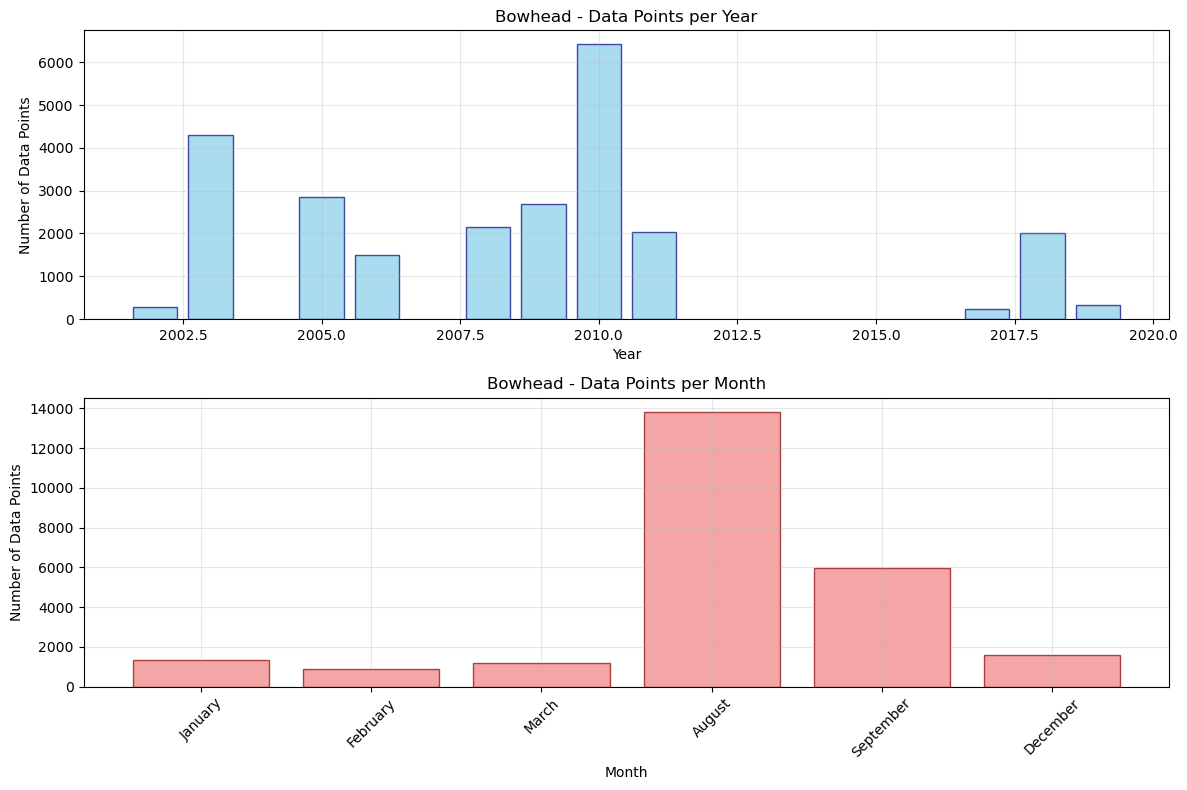

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
# Year distribution
year_counts = bowhead_data.groupby('year').size()
ax1.bar(year_counts.index, year_counts.values, color='skyblue', alpha=0.7, edgecolor='navy')
ax1.set_title(f'Bowhead - Data Points per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Data Points')
ax1.grid(True, alpha=0.3)

# Month distribution
month_counts = bowhead_data.groupby('month').size()
month_names = [pd.Timestamp(2020, month, 1).strftime('%B') for month in month_counts.index]
ax2.bar(range(len(month_counts)), month_counts.values, color='lightcoral', alpha=0.7, edgecolor='darkred')
ax2.set_title(f'Bowhead - Data Points per Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Data Points')
ax2.set_xticks(range(len(month_counts)))
ax2.set_xticklabels(month_names, rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We can see that we do not have data points for the main migration periods which are April to June. However, we might be able to see some movement still during early spring months August. We also note that we have a decent amount of data for Bowhead whales for the year of 2010.

2010 is a special year as that year the Northwest Passage was largely free of sea ice by August 10th, providing unusual access. It has been reported that Two adult male bowhead whales, one from West Greenland and one from Alaska (different stocks), entered the Northwest Passage from opposite directions. They spent over two weeks in Viscount Melville Sound in September, coming within 130 km of each other, before returning to their normal seasonal ranges. (Heide-Jørgensen, Mads Peter, et al. "The Northwest Passage opens for bowhead whales." Biology letters 8.2 (2012): 270-273.)

For comparison, we select the years 2003 and 2018 as alternative years with decent amount of data points and both more and less ice coverage respectively (relative to 2010 based on reported September minimum ice extent https://climate.copernicus.eu/sea-ice-cover-september-2024)

We will also filter telemetry data for the West side of Greenland, which is where the main migration movement is expected to happen

In [ ]:
print("Whale telemetry config:")
print(f"Species filter: {config.notebooks.whale_telemetry.filters.species}")
print(f"Side filter: {config.notebooks.whale_telemetry.filters.side}")
print(f"Start month: {config.notebooks.whale_telemetry.date_filter.start_month}")
print(f"End month: {config.notebooks.whale_telemetry.date_filter.end_month}")
print(f"Target years: {config.notebooks.whale_telemetry.date_filter.target_years}")

# Use config to filter the data
filtered_data = whale_data[
    (whale_data['species'] == config.notebooks.whale_telemetry.filters.species) &
    (whale_data['side'] == config.notebooks.whale_telemetry.filters.side) &
    (whale_data['month'] >= config.notebooks.whale_telemetry.date_filter.start_month) &
    (whale_data['month'] <= config.notebooks.whale_telemetry.date_filter.end_month) &
    (whale_data['year'].isin(config.notebooks.whale_telemetry.date_filter.target_years))
]

print(f"\nFiltered records: {len(filtered_data):,}")

Whale telemetry config:
Species filter: Bw
Side filter: West
Start month: 7
End month: 9
Target years: [2003, 2010, 2018]

Filtered records: 10,985


## 4. Whale Data Visualization

Let's visualize one day of the whale dataset to get a better idea

/Users/shosking/miniconda3/envs/torch_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


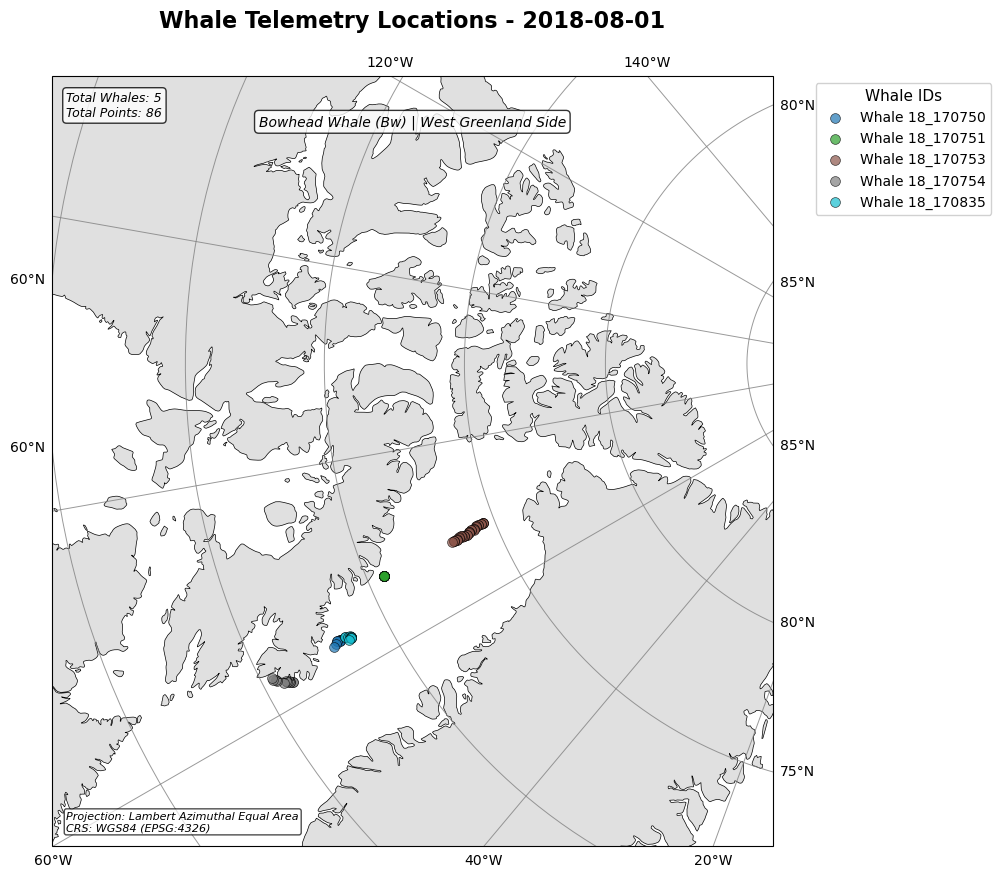

In [ ]:
def create_separate_data_plots(whale_data_filtered: pd.DataFrame, config) -> None:
    """
    Create whale data visualization for one day from a randomly selected year.
    
    Args:
        whale_data_filtered: Filtered whale telemetry data
        config: Configuration object
    """

    # Get visualization parameters from config
    viz_config = config.notebooks.visualization
    
    # Get the first day's data for this year
    first_date = whale_data_year['dateTime'].min().date()
    whale_data_date = whale_data_year[whale_data_year['dateTime'].dt.date == first_date]
    
    # Create whale locations plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10), 
                          subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
                              central_longitude=0, central_latitude=90)})
    
    # Set Arctic extent (West Greenland / Canadian Arctic)
    plot_extent = [-110, -55, 60, 85]
    ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
    
    # Add coastlines and land features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7)
    
    # Plot whale locations if data exists
    if not whale_data_date.empty:
        # Plot whale locations with different colors per whale ID
        unique_whales = whale_data_date['id'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_whales)))
        
        for i, whale_id in enumerate(unique_whales):
            whale_points = whale_data_date[whale_data_date['id'] == whale_id]
            ax.scatter(whale_points['lon'], whale_points['lat'], 
                       c=[colors[i]], label=f'Whale {whale_id}', 
                       s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                       transform=ccrs.PlateCarree())
        
        # Add legend
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10,
                  title='Whale IDs', title_fontsize=11, framealpha=0.9)
        
        # Add data summary info
        ax.text(0.02, 0.98, f'Total Whales: {len(unique_whales)}\nTotal Points: {len(whale_data_date)}', 
                transform=ax.transAxes, fontsize=9, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        ax.text(0.5, 0.5, 'No whale data for this year', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
    
    # Set title
    ax.set_title(f'Whale Telemetry Locations - {first_date}', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Add informative subtitle
    ax.text(0.5, 0.95, 'Bowhead Whale (Bw) | West Greenland Side', 
            transform=ax.transAxes, ha='center', va='top', 
            fontsize=10, style='italic', bbox=dict(boxstyle='round,pad=0.3', 
            facecolor='white', alpha=0.8))
    
    # Add gridlines
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                linewidth=0.7, alpha=0.8, color='gray')
    
    # Add coordinate system info
    ax.text(0.02, 0.02, 'Projection: Lambert Azimuthal Equal Area\nCRS: WGS84 (EPSG:4326)', 
            transform=ax.transAxes, fontsize=8, style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    plt.show()

# Filter whale data for year
whale_data_year = filtered_data[filtered_data['year'] == 2018]
    
create_separate_data_plots(whale_data_filtered=whale_data_year, config=config)

We can see that on this random day we have data for 5 unique whales and for some of these whales we have several data points indicating their travel trajectory.

## 5. Sea Ice Data

We will now add sea ice to the mix!

Let's load the prepared Zarr sea ice datasets using the lightning SingleDataset format. This loads OSISAF sea ice concentration data for each target year and applies sanity checks to verify data integrity.

In [ ]:
# Load sea ice datasets using SingleDataset
from icenet_mp.data_loaders import SingleDataset

# Get the base path from config
base_path = Path(config.base_path)

# Dictionary to store datasets for each year
sea_ice_datasets = {}

# Get target years from whale telemetry config
target_years = config.notebooks.whale_telemetry.date_filter.target_years

for year in target_years:
    dataset_name = f"nbsamp-sicnorth-osisaf-25k-{year}-{year}-24h-v1"
    dataset_path = base_path / "data" / "anemoi" / f"{dataset_name}.zarr"
    try:
        # Create SingleDataset using the lightning format
        # This will load the data using anemoi.datasets.data.open_dataset internally
        sea_ice_datasets[str(year)] = SingleDataset(name=dataset_name, input_files=[dataset_path])
    except Exception as e:
        print(f"Failed to load sea ice dataset for {year}: {e}")
print(sea_ice_datasets)

{'2003': <icenet_mp.data_loaders.single_dataset.SingleDataset object at 0x30bf7b350>, '2010': <icenet_mp.data_loaders.single_dataset.SingleDataset object at 0x31b11f7d0>, '2018': <icenet_mp.data_loaders.single_dataset.SingleDataset object at 0x31c6c3910>}


[-5400000.0, 5400000.0, -5400000.0, 5400000.0]


/Users/shosking/miniconda3/envs/torch_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


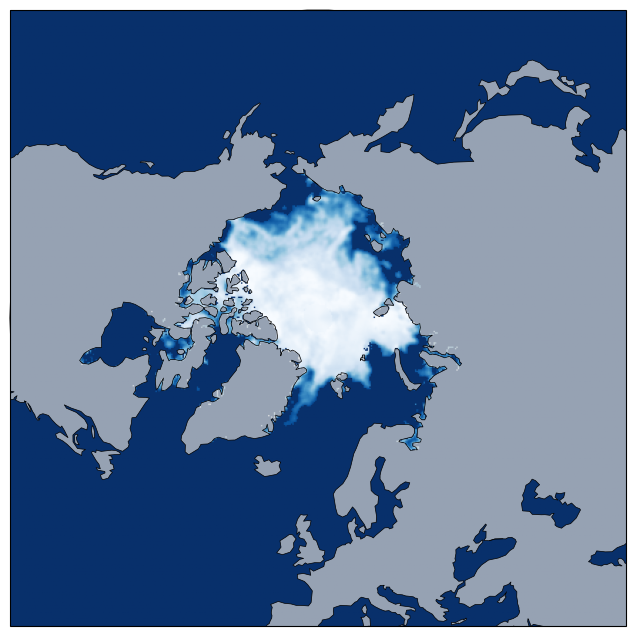

In [ ]:
# Get the first dataset (any year)
year, dataset = next(iter(sea_ice_datasets.items()))

# Get first day's data
first_day_data = dataset[0]  # Shape: (C, H, W)
first_day_data = first_day_data.squeeze(0)  # Remove channel dimension -> (H, W)

# Create plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.NorthPolarStereo()})

# Data’s CRS (from the manual): LAEA, pole-centered, WGS84, lon0=0
src_crs = ccrs.LambertAzimuthalEqualArea(
    central_longitude=0, central_latitude=90,
    globe=ccrs.Globe(ellipse='WGS84')
)

nrows, ncols = 432, 432
px = 25_000.0  # meters per pixel

half_w = (ncols * px) / 2.0
half_h = (nrows * px) / 2.0
extent = [-half_w, half_w, -half_h, half_h]   # [xmin, xmax, ymin, ymax] in meters
print(extent) 
ax = plt.axes(projection=src_crs)

# Plot sea ice data using imshow
im1 = ax.imshow(
    first_day_data,
    vmin=0, vmax=1,
    transform=src_crs,         
    extent=extent,             # Use the EASE2 grid extent
    origin='upper',
    cmap='Blues_r'            # Blue to white colormap (white = high concentration)
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7,zorder=0)

plt.show()

### Generate animation

We now overlay whale telemetry data on top of SIC to generate an animation.

In [ ]:
import io
import urllib.request
import cartopy.io.img_tiles as cimgt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.lines import Line2D

class ArcGISWorldImagery(cimgt.GoogleWTS):
    """High-resolution satellite imagery from ArcGIS (no API key required)."""
    def _image_url(self, tile):
        x, y, z = tile
        return f'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'


_github_logo_cache = None

def get_github_logo():
    global _github_logo_cache
    if _github_logo_cache is None:
        url = "https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png"
        with urllib.request.urlopen(url) as response:
            _github_logo_cache = plt.imread(io.BytesIO(response.read()))
    return _github_logo_cache


def create_animation(sea_ice_dataset: 'SingleDataset', whale_data_year: pd.DataFrame, year: str) -> 'matplotlib.animation.FuncAnimation':
    """
    Create animation for a single year's dataset.
    Each day is shown for 1 second (hardcoded).

    Args:
        sea_ice_dataset: Single year's sea ice dataset
        whale_data_year: Filtered whale telemetry data for this year
        year: Year as string for title

    Returns:
        Single animation object
    """
    from matplotlib.colors import ListedColormap

    total_timesteps = len(sea_ice_dataset)
    if total_timesteps == 0:
        return None

    # Pure white colormap with sqrt alpha ramp: transparent at 0 (open water),
    # quickly becoming bright white as ice concentration increases.
    n = 256
    ice_rgba = np.ones((n, 4))
    ice_rgba[:, 3] = np.power(np.linspace(0, 1, n), 0.5) * 0.95
    ice_cmap = ListedColormap(ice_rgba)

    trail_days = 5

    def dot_colour(days_back):
        """Interpolate from red (current) to yellow (oldest trail)."""
        t = days_back / trail_days
        return (1.0, t, 0.0)

    def dot_size(days_back):
        return max(20, 120 - days_back * 18)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10),
                          subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
                              central_latitude=90, central_longitude=0)})

    plot_extent = [-110, -55, 60, 85]
    ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

    # High-resolution satellite background (tiles cached after first download)
    ax.add_image(ArcGISWorldImagery(cache=True), 4)

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                linewidth=0.5, alpha=0.6, color='white')

    # Bowhead whale legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=(1.0, 0.0, 0.0),
               markeredgecolor='black', markersize=11, label='Current position'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=(1.0, 0.6, 0.0),
               markeredgecolor='black', markersize=9, label='3 days ago'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=(1.0, 1.0, 0.0),
               markeredgecolor='black', markersize=7, label='5 days ago'),
    ]
    legend = ax.legend(
        handles=legend_elements,
        title='Bowhead Whale\ntelemetry',
        title_fontsize=9,
        loc='upper left',
        fontsize=8,
        framealpha=0.9,
        facecolor='white',
        edgecolor='gray',
    )
    legend.set_zorder(25)

    # GitHub logo + URL (static overlay — drawn once, persists through all frames)
    try:
        github_logo = get_github_logo()
        imagebox = OffsetImage(github_logo, zoom=0.07)
        ab = AnnotationBbox(imagebox, (0.02, 0.03),
                            xycoords='axes fraction',
                            frameon=False,
                            box_alignment=(0, 0.5),
                            zorder=25)
        ax.add_artist(ab)
        ax.text(0.12, 0.03, 'github.com/alan-turing-institute/icenet-mp',
               transform=ax.transAxes, ha='left', va='center',
               fontsize=8, color='white', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6),
               zorder=25)
    except Exception as e:
        print(f"Warning: Could not add GitHub logo: {e}")

    sea_ice_plot = None
    whale_scatter = None
    date_text = None

    def get_daily_whale_positions(df: pd.DataFrame, target_date: pd.Timestamp, days_back: int = 0) -> pd.DataFrame:
        if days_back > 0:
            target_date = target_date - pd.Timedelta(days=days_back)
        day_data = df[df['dateTime'].dt.date == target_date.date()]
        if day_data.empty:
            return pd.DataFrame()
        return day_data.groupby('id').tail(1)

    def animate(frame_idx):
        nonlocal sea_ice_plot, whale_scatter, date_text

        sea_ice_data = sea_ice_dataset[frame_idx].squeeze(0)

        frame_date = sea_ice_dataset.start_date + pd.Timedelta(days=frame_idx)
        frame_date_str = str(frame_date)[:10]
        frame_date_pd = pd.Timestamp(frame_date)

        if sea_ice_plot is not None:
            sea_ice_plot.remove()
        if whale_scatter is not None:
            whale_scatter.remove()
        if date_text is not None:
            date_text.remove()

        nrows, ncols = 432, 432
        px = 25_000.0
        half_w = (ncols * px) / 2.0
        half_h = (nrows * px) / 2.0
        extent = [-half_w, half_w, -half_h, half_h]

        sea_ice_plot = ax.imshow(
            sea_ice_data,
            vmin=0, vmax=1,
            transform=ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0),
            extent=extent,
            origin='upper',
            cmap=ice_cmap,
            zorder=2
        )

        all_lons, all_lats, all_colors, all_sizes = [], [], [], []

        current_whale_data = get_daily_whale_positions(whale_data_year, frame_date_pd)
        if not current_whale_data.empty:
            unique_whales = current_whale_data['id'].unique()

            for whale_id in unique_whales:
                for days_back in range(trail_days, 0, -1):
                    trail_data = get_daily_whale_positions(whale_data_year, frame_date_pd, days_back)
                    if not trail_data.empty:
                        pt = trail_data[trail_data['id'] == whale_id]
                        if not pt.empty:
                            all_lons.append(pt['lon'].iloc[0])
                            all_lats.append(pt['lat'].iloc[0])
                            all_colors.append(dot_colour(days_back))
                            all_sizes.append(dot_size(days_back))

                pt = current_whale_data[current_whale_data['id'] == whale_id]
                if not pt.empty:
                    all_lons.append(pt['lon'].iloc[0])
                    all_lats.append(pt['lat'].iloc[0])
                    all_colors.append(dot_colour(0))
                    all_sizes.append(dot_size(0))

            if all_lons:
                whale_scatter = ax.scatter(
                    all_lons, all_lats,
                    c=all_colors, s=all_sizes,
                    edgecolors='black', linewidth=0.6,
                    transform=ccrs.PlateCarree(), zorder=20
                )

        date_text = ax.text(0.5, 0.97, frame_date_str,
                           transform=ax.transAxes, ha='center', va='top',
                           fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), zorder=21)

        return sea_ice_plot, whale_scatter, date_text

    anim = animation.FuncAnimation(
        fig, animate, frames=total_timesteps,
        interval=1000, blit=False, repeat=True
    )

    plt.close(fig)
    return anim

In [ ]:
from IPython.display import Video

sel_year = '2010'
anim = create_animation(sea_ice_datasets[sel_year], filtered_data, sel_year)

output_path = 'whale_corridors_2010.mp4'
writer = animation.FFMpegWriter(fps=1, bitrate=2000)
anim.save(output_path, writer=writer, savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0.05})
plt.close('all')

Video(output_path, embed=True)

### Animation of whales / ships 

In [ ]:
def create_animation_lines(sea_ice_dataset: 'SingleDataset', whale_data_year: pd.DataFrame, year: str,
                           ship_df: pd.DataFrame = None) -> 'matplotlib.animation.FuncAnimation':
    """
    Create animation for a single year's dataset.
    Whale tracks fade from blue (oldest) to cyan (newest).
    Ship tracks fade from orange (oldest, transparent) to red (newest, opaque).
    Each day is shown for 1 second (hardcoded).
    """
    from matplotlib.colors import ListedColormap
    from matplotlib.collections import LineCollection

    n = 256
    ice_rgba = np.ones((n, 4))
    ice_rgba[:, 3] = np.power(np.linspace(0, 1, n), 0.5) * 0.95
    ice_cmap = ListedColormap(ice_rgba)

    max_gap = pd.Timedelta(days=2)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10),
                          subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
                              central_latitude=90, central_longitude=0)})

    plot_extent = [-110, -55, 60, 85]
    ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

    ax.add_image(ArcGISWorldImagery(cache=True), 4)

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                linewidth=0.5, alpha=0.6, color='white')

    legend_elements = [
        Line2D([0], [0], color='blue', linewidth=2, label='Older whale track'),
        Line2D([0], [0], color='cyan', linewidth=2, label='Recent whale track'),
        Line2D([0], [0], marker='o', linestyle='', markerfacecolor='cyan',
               markeredgecolor='black', markersize=9, label='Whale current position'),
    ]
    if ship_df is not None and not ship_df.empty:
        legend_elements += [
            Line2D([0], [0], color='orange', linewidth=2, label='Older ship track'),
            Line2D([0], [0], color='red', linewidth=2, label='Recent ship track'),
            Line2D([0], [0], marker='o', linestyle='', markerfacecolor='red',
                   markeredgecolor='black', markersize=9, label='Ship current position'),
        ]
    legend = ax.legend(handles=legend_elements, title='Track data',
                       title_fontsize=9, loc='upper left', fontsize=8,
                       framealpha=0.9, facecolor='white', edgecolor='gray')
    legend.set_zorder(25)

    github_logo = get_github_logo()
    imagebox = OffsetImage(github_logo, zoom=0.07)
    ab = AnnotationBbox(imagebox, (0.02, 0.03), xycoords='axes fraction',
                        frameon=False, box_alignment=(0, 0.5), zorder=25)
    ax.add_artist(ab)
    ax.text(0.12, 0.03, 'github.com/alan-turing-institute/icenet-mp',
            transform=ax.transAxes, ha='left', va='center', fontsize=12,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6), zorder=25)

    sea_ice_plot = None
    whale_artists = []
    date_text = None

    def get_daily_whale_positions(df, target_date):
        day_data = df[df['dateTime'].dt.date == target_date.date()]
        if day_data.empty:
            return pd.DataFrame()
        return day_data.groupby('id').tail(1)

    def track_to_colored_collection(track):
        lons = track['lon'].values
        lats = track['lat'].values
        times = track['dateTime'].values
        try:
            duration = float((times[-1] - times[0]) / np.timedelta64(1, 'ns'))
        except Exception:
            duration = 1.0
        segments, colors = [], []
        for i in range(len(lons) - 1):
            if pd.Timestamp(times[i + 1]) - pd.Timestamp(times[i]) > max_gap:
                continue
            segments.append([[lons[i], lats[i]], [lons[i + 1], lats[i + 1]]])
            t = float((times[i] - times[0]) / np.timedelta64(1, 'ns')) / duration if duration > 0 else 1.0
            colors.append((0.0, t, 1.0))  # blue (oldest) → cyan (newest)
        return LineCollection(segments, colors=colors, linewidth=2,
                              transform=ccrs.PlateCarree(), zorder=19)

    def ship_tracks_for_date(frame_date):
        visible = ship_df[ship_df['dateTime'].dt.date <= frame_date.date()]
        if visible.empty:
            return None, [], []
        segments, colors = [], []
        current_lons, current_lats = [], []
        for mmsi, track in visible.groupby('mmsi'):
            track = track.sort_values('dateTime')
            lons = track['lon'].values
            lats = track['lat'].values
            times = track['dateTime'].values
            try:
                duration = float((times[-1] - times[0]) / np.timedelta64(1, 'ns'))
            except Exception:
                duration = 1.0
            for i in range(len(lons) - 1):
                if pd.Timestamp(times[i + 1]) - pd.Timestamp(times[i]) > max_gap:
                    continue
                segments.append([[lons[i], lats[i]], [lons[i + 1], lats[i + 1]]])
                t = float((times[i] - times[0]) / np.timedelta64(1, 'ns')) / duration if duration > 0 else 1.0
                colors.append((1.0, 0.65 * (1.0 - t), 0.0, 0.1 + 0.9 * t))  # orange (oldest, transparent) → red (newest, opaque)
            current_lons.append(float(lons[-1]))
            current_lats.append(float(lats[-1]))
        lc = LineCollection(segments, colors=colors, linewidth=2,
                            transform=ccrs.PlateCarree(), zorder=10) if segments else None
        return lc, current_lons, current_lats

    def animate(frame_idx):
        nonlocal sea_ice_plot, whale_artists, date_text
        sea_ice_data = sea_ice_dataset[frame_idx].squeeze(0)
        frame_date = sea_ice_dataset.start_date + pd.Timedelta(days=frame_idx)
        frame_date_str = str(frame_date)[:10]
        frame_date_pd = pd.Timestamp(frame_date)

        if sea_ice_plot is not None:
            sea_ice_plot.remove()
        for artist in whale_artists:
            artist.remove()
        whale_artists.clear()
        if date_text is not None:
            date_text.remove()

        nrows, ncols = 432, 432
        px = 25_000.0
        extent = [-(ncols * px) / 2, (ncols * px) / 2, -(nrows * px) / 2, (nrows * px) / 2]

        sea_ice_plot = ax.imshow(sea_ice_data, vmin=0, vmax=1,
            transform=ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0),
            extent=extent, origin='upper', cmap=ice_cmap, zorder=2)

        if ship_df is not None and not ship_df.empty:
            ship_lc, ship_lons, ship_lats = ship_tracks_for_date(frame_date_pd)
            if ship_lc is not None:
                ax.add_collection(ship_lc)
                whale_artists.append(ship_lc)
            if ship_lons:
                ship_sc = ax.scatter(ship_lons, ship_lats, c=['red'], s=80,
                                     edgecolors='black', linewidth=0.6,
                                     transform=ccrs.PlateCarree(), zorder=20)
                whale_artists.append(ship_sc)

        current_whale_data = get_daily_whale_positions(whale_data_year, frame_date_pd)
        if not current_whale_data.empty:
            for whale_id in current_whale_data['id'].unique():
                whale_track = whale_data_year[
                    (whale_data_year['id'] == whale_id) &
                    (whale_data_year['dateTime'].dt.date <= frame_date_pd.date())
                ].sort_values('dateTime')
                if len(whale_track) >= 2:
                    lc = track_to_colored_collection(whale_track)
                    ax.add_collection(lc)
                    whale_artists.append(lc)
                if not whale_track.empty:
                    sc = ax.scatter([whale_track['lon'].iloc[-1]], [whale_track['lat'].iloc[-1]],
                                    c=['cyan'], s=80, edgecolors='black', linewidth=0.6,
                                    transform=ccrs.PlateCarree(), zorder=21)
                    whale_artists.append(sc)

        date_text = ax.text(0.5, 0.97, frame_date_str, transform=ax.transAxes,
                           ha='center', va='top', fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), zorder=22)
        return [sea_ice_plot] + whale_artists + [date_text]

    anim = animation.FuncAnimation(fig, animate, frames=len(sea_ice_dataset),
                                   interval=1000, blit=False, repeat=True)
    plt.close(fig)
    return anim


The voyages data is downloaded from GFW, for August / September 2018: https://globalfishingwatch.org/data-download/datasets/public-voyages-confidence-4%3Av20220922 

In [ ]:
import s2sphere

# Re-run S2 filtering without any API calls to recover the vessel ID list
_voyages_dir = Path(config.notebooks.whale_telemetry.input.csv.path).parent
_year = 2018
_xmin, _xmax, _ymin, _ymax = -110, -55, 60, 85

dfs = []
for month in [8, 9]:
    fname = _voyages_dir / f"voyages_{_year}{month:02d}.csv"
    if fname.exists():
        dfs.append(pd.read_csv(fname))

df_v = pd.concat(dfs, ignore_index=True)

all_tokens = pd.unique(df_v[['trip_start_anchorage_s2id', 'trip_end_anchorage_s2id']].values.ravel('K'))
arctic_s2ids = set()
for token in all_tokens:
    if not isinstance(token, str):
        continue
    try:
        ll = s2sphere.CellId.from_token(token).to_lat_lng()
        if _xmin <= ll.lng().degrees <= _xmax and _ymin <= ll.lat().degrees <= _ymax:
            arctic_s2ids.add(token)
    except Exception:
        pass

arctic_mask = (
    df_v['trip_start_anchorage_s2id'].isin(arctic_s2ids) |
    df_v['trip_end_anchorage_s2id'].isin(arctic_s2ids)
)
arctic_vessel_ids = df_v.loc[arctic_mask, 'vessel_id'].dropna().astype(str).unique().tolist()
print(f"Found {len(arctic_vessel_ids)} vessel IDs with Arctic voyages:")
for vid in sorted(arctic_vessel_ids):
    print(vid)

Ships are downloaded from GFW: https://globalfishingwatch.org/map/vessel-search

I selected a set of ships from the list provided by the above cell. I selected the following vessels:
    - ZELADA DESGAGNES
    - SAPUTI
    - ROSAIREADESGAGNES
    - AKADEMIK SERGEY VAVILOV
    - KIVIUQ II 
    - ARCTIC
    - CLAUDEADESGAGNES
    - SARAH DESGAGNES
    - LEEWAYODYSSEY
    - MIENA DESGAGNES


In [ ]:
data_dir = Path(config.notebooks.whale_telemetry.input.csv.path).parent

track_files = sorted(data_dir.glob("track-data*.csv"))
print("Found track files:", track_files)

if track_files:
    ship_track_csv = pd.concat(
        [pd.read_csv(f) for f in track_files], ignore_index=True
    )
    print(ship_track_csv.shape)
    print(ship_track_csv.dtypes)
    display(ship_track_csv.head())


In [ ]:
from IPython.display import Video

sel_year = '2018'

# Normalise ship track CSV columns to match create_animation_lines expectations
ship_data = ship_track_csv[['seg_id', 'timestamp', 'lon', 'lat']].rename(
    columns={'seg_id': 'mmsi', 'timestamp': 'dateTime'}
).copy()
ship_data['dateTime'] = pd.to_datetime(ship_data['dateTime'])

print(f"Ship positions: {len(ship_data)}, segments: {ship_data['mmsi'].nunique()}")

anim = create_animation_lines(
    sea_ice_datasets[sel_year],
    filtered_data[filtered_data['year'] == int(sel_year)],
    sel_year,
    ship_df=ship_data,
)

output_path = 'whale_corridors_2018.mp4'
writer = animation.FFMpegWriter(fps=4, bitrate=2000)
anim.save(output_path, writer=writer, savefig_kwargs={'pad_inches': 0.05})
plt.close('all')

Video(output_path, embed=True)
